# AI-Based School Safety & Real-Time Emergency Alert System
### Major Project Starter using Multiclass Logistic Regression

**Project idea:** Use simulated camera/sensor readings to classify the current situation into:

- **0 — Safe**
- **1 — Normal Alert**
- **2 — High-Priority Emergency**

The project also demonstrates:
- automatic alert generation,
- simulated real-time monitoring,
- automatic **CLEAR** when the situation returns to safe,
- a simple live-status display, and
- an alert-history table.

> **Academic note:** A real emergency system would require validated sensors, reliable communications, extensive safety testing, and human oversight.

## Suggested problem statement

Schools and campuses need a fast way to identify abnormal safety conditions such as smoke, fire, gas leakage, unusual heat, crowd disturbance, or other emergencies.  
This project builds an AI-based prototype that analyzes sensor readings and predicts the severity of the situation. Based on the prediction, it produces either a normal alert or a high-priority emergency alert. When later readings become safe, the system automatically clears the active alert.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)


In [16]:
# Load the dataset
df = pd.read_csv('https://github.com/YBIFoundation/Internship/raw/main/SchoolSafetyEmergencyDataset.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1200, 12)


,temperature_c,smoke_level,co_ppm,gas_level,sound_db,crowd_count,motion_index,flame_detected,event_duration_min,incident_type,severity,severity_label
0,28.10,22.50,29.20,84.84,67.82,30,33.72,0,4.52,Unusual Heat,1,Normal Alert
1,26.58,0.00,2.95,23.93,65.76,27,11.59,0,1.30,Safe / Normal Activity,0,Safe
2,39.43,37.81,2.37,40.36,79.48,48,55.90,0,7.22,Unusual Heat,1,Normal Alert
3,33.20,51.50,25.54,88.17,55.58,20,91.67,0,1.63,Minor Smoke,1,Normal Alert
4,29.10,14.98,3.40,13.24,51.74,11,83.63,0,3.83,Safe / Normal Activity,0,Safe


In [21]:
# Check class distribution
class_names = {
    0: "Safe",
    1: "Normal Alert",
    2: "High-Priority Emergency"
}


In [22]:
print(df["severity"].value_counts().sort_index())

severity
0    735
1    324
2    141
Name: count, dtype: int64


In [23]:
print(df["severity_label"].value_counts())

severity_label
Safe                       735
Normal Alert               324
High-Priority Emergency    141
Name: count, dtype: int64


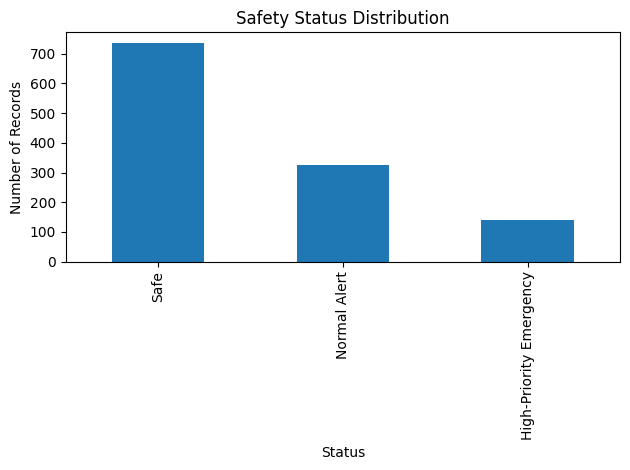

In [24]:
# Optional quick visualization
df["severity_label"].value_counts().plot(
    kind="bar",
    title="Safety Status Distribution"
)
plt.xlabel("Status")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Model features

The model uses simulated sensor readings:

- temperature
- smoke level
- carbon monoxide (CO)
- gas level
- sound level
- crowd count
- motion index
- flame detection
- event duration

`incident_type` is kept only for explanation/history and is **not used** as a model input.

The synthetic class ranges intentionally overlap, so the model will make some mistakes. This gives students a more realistic accuracy score and confusion matrix for discussion.


In [26]:
feature_cols = [
    "temperature_c",
    "smoke_level",
    "co_ppm",
    "gas_level",
    "sound_db",
    "crowd_count",
    "motion_index",
    "flame_detected",
    "event_duration_min"
]

X = df[feature_cols]
y = df["severity"]

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 960
Testing rows : 240


In [27]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
# Build and train a Logistic Regression pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [30]:
# Model Evaluation
print(classification_report(
    y_test,
    pred,
    target_names=["Safe", "Normal Alert", "High-Priority Emergency"]
))

                         precision    recall  f1-score   support

                   Safe       0.97      0.97      0.97       147
           Normal Alert       0.89      0.88      0.88        65
High-Priority Emergency       0.87      0.93      0.90        28

               accuracy                           0.94       240
              macro avg       0.91      0.92      0.92       240
           weighted avg       0.94      0.94      0.94       240



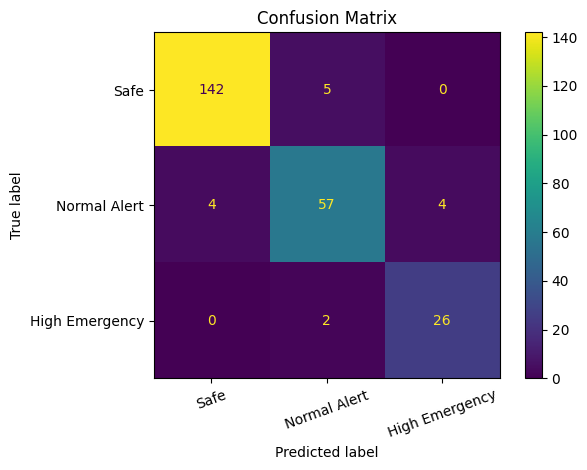

In [7]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=["Safe", "Normal Alert", "High Emergency"],
    xticks_rotation=20
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Convert predictions into alerts

In a real deployment, this function could be connected to an SMS/e-mail/notification service.  
Here we only simulate the alert text so that the project remains simple and safe for a college internship.

In [33]:
def create_alert_message(predicted_class):
    if predicted_class == 0:
        return "CLEAR / SAFE: No active emergency."
    elif predicted_class == 1:
        return "NORMAL ALERT: Please inspect the location."
    else:
        return "HIGH-PRIORITY EMERGENCY: Immediate response required!"

# Example
for value in [0, 1, 2]:
    print(value, "->", create_alert_message(value))

0 -> CLEAR / SAFE: No active emergency.
1 -> NORMAL ALERT: Please inspect the location.
2 -> HIGH-PRIORITY EMERGENCY: Immediate response required!


## Predict one new sensor reading

Change the values below to test different situations.

In [34]:
new_reading = pd.DataFrame([{
    "temperature_c": 65,
    "smoke_level": 88,
    "co_ppm": 40,
    "gas_level": 92,
    "sound_db": 101,
    "crowd_count": 48,
    "motion_index": 90,
    "flame_detected": 1,
    "event_duration_min": 8
}])

prediction = int(model.predict(new_reading)[0])
probabilities = model.predict_proba(new_reading)[0]

print("Predicted status:", class_names[prediction])
print(create_alert_message(prediction))
print()
print("Class probabilities:")
for class_id, probability in zip(model.classes_, probabilities):
    print(f"{class_names[int(class_id)]:25s}: {probability:.3f}")

Predicted status: High-Priority Emergency
HIGH-PRIORITY EMERGENCY: Immediate response required!

Class probabilities:
Safe                     : 0.000
Normal Alert             : 0.000
High-Priority Emergency  : 1.000


## Simulated real-time monitoring and automatic alert clearing

The next section treats test rows as if they were arriving one after another from sensors.

**Logic**
1. If the model predicts **Normal Alert**, create a normal alert.
2. If it predicts **High-Priority Emergency**, create an emergency alert.
3. If there was an active alert and the next condition is **Safe**, mark the earlier condition as cleared.
4. Save all changes in an alert-history table.

In [35]:
# Create a demonstration stream:
# first include some risky rows, then safe rows so the CLEAR logic is visible.
demo_stream = pd.concat([
    df[df["severity"] == 1].sample(3, random_state=10),
    df[df["severity"] == 2].sample(4, random_state=20),
    df[df["severity"] == 0].sample(4, random_state=30),
    df.sample(9, random_state=40)
]).reset_index(drop=True)

alert_history = []
active_alert = False

for i, row in demo_stream.iterrows():
    sample = row[feature_cols].to_frame().T
    predicted = int(model.predict(sample)[0])
    predicted_label = class_names[predicted]

    if predicted == 0:
        if active_alert:
            system_action = "CLEAR: Previous alert closed automatically"
            active_alert = False
        else:
            system_action = "SAFE: No active alert"
    elif predicted == 1:
        system_action = "NORMAL ALERT: Inspection required"
        active_alert = True
    else:
        system_action = "HIGH-PRIORITY EMERGENCY: Immediate response required"
        active_alert = True

    alert_history.append({
        "stream_step": i + 1,
        "incident_type": row["incident_type"],
        "temperature_c": row["temperature_c"],
        "smoke_level": row["smoke_level"],
        "flame_detected": row["flame_detected"],
        "predicted_status": predicted_label,
        "system_action": system_action
    })

history_df = pd.DataFrame(alert_history)
history_df

,stream_step,incident_type,temperature_c,smoke_level,flame_detected,predicted_status,system_action
0,1,Minor Smoke,45.42,52.49,0,Normal Alert,NORMAL ALERT: Inspection required
1,2,Possible Gas Issue,42.38,40.53,0,High-Priority Emergency,HIGH-PRIORITY EMERGENCY: Immediate response re...
2,3,Possible Gas Issue,29.58,27.61,0,Normal Alert,NORMAL ALERT: Inspection required
3,4,Critical Gas Leak,52.28,43.23,0,Normal Alert,NORMAL ALERT: Inspection required
4,5,Severe Heat Emergency,54.51,71.50,0,High-Priority Emergency,HIGH-PRIORITY EMERGENCY: Immediate response re...
5,6,Fire Emergency,47.96,38.08,1,High-Priority Emergency,HIGH-PRIORITY EMERGENCY: Immediate response re...
6,7,Fire Emergency,51.01,71.21,0,High-Priority Emergency,HIGH-PRIORITY EMERGENCY: Immediate response re...
7,8,Safe / Normal Activity,32.01,30.27,0,Safe,CLEAR: Previous alert closed automatically
8,9,Safe / Normal Activity,22.75,27.55,0,Safe,SAFE: No active alert
9,10,Safe / Normal Activity,26.67,17.20,0,Safe,SAFE: No active alert


In [36]:
# Simple dashboard-style latest status
latest = history_df.iloc[-1]

print("=" * 60)
print("        SCHOOL SAFETY MONITORING DASHBOARD")
print("=" * 60)
print("Current predicted status :", latest["predicted_status"])
print("Current system action    :", latest["system_action"])
print("Temperature (C)          :", latest["temperature_c"])
print("Smoke level              :", latest["smoke_level"])
print("Flame detected           :", latest["flame_detected"])
print("=" * 60)

print("\nRecent alert history:")
display(history_df.tail(10))

        SCHOOL SAFETY MONITORING DASHBOARD
Current predicted status : Normal Alert
Current system action    : NORMAL ALERT: Inspection required
Temperature (C)          : 35.06
Smoke level              : 52.27
Flame detected           : 0

Recent alert history:


,stream_step,incident_type,temperature_c,smoke_level,flame_detected,predicted_status,system_action
10,11,Safe / Normal Activity,26.73,40.75,0,Normal Alert,NORMAL ALERT: Inspection required
11,12,Crowd Disturbance,33.88,32.80,0,Normal Alert,NORMAL ALERT: Inspection required
12,13,Safe / Normal Activity,26.66,15.10,0,Safe,CLEAR: Previous alert closed automatically
13,14,Safe / Normal Activity,22.64,35.25,0,Safe,SAFE: No active alert
14,15,Possible Gas Issue,36.68,31.63,0,Normal Alert,NORMAL ALERT: Inspection required
15,16,Safe / Normal Activity,20.32,0.00,0,Safe,CLEAR: Previous alert closed automatically
16,17,Safe / Normal Activity,26.42,26.64,0,Normal Alert,NORMAL ALERT: Inspection required
17,18,Safe / Normal Activity,28.64,17.79,0,Safe,CLEAR: Previous alert closed automatically
18,19,Safe / Normal Activity,36.19,34.74,0,Normal Alert,NORMAL ALERT: Inspection required
19,20,Possible Gas Issue,35.06,52.27,0,Normal Alert,NORMAL ALERT: Inspection required


## How this can become a stronger major project later

After the basic internship version works, students can extend it with:

- webcam/fire-smoke image detection,
- Arduino/ESP32 or IoT sensors,
- SMS/e-mail/WhatsApp notification integration,
- Streamlit or Power BI dashboard,
- database-based alert history,
- location/room-wise monitoring,
- escalation rules,
- acknowledgement by security staff,
- and automatic incident closure after repeated safe readings.

For the **internship submission**, the Logistic Regression prototype is sufficient to demonstrate the complete AI workflow: data → model → prediction → alert → clear → history.

## Suggested project report modules

1. Introduction and problem statement  
2. Objective and scope  
3. Dataset and sensor variables  
4. Data preprocessing  
5. Logistic Regression model  
6. Model evaluation  
7. Alert classification logic  
8. Real-time monitoring simulation  
9. Dashboard and alert history  
10. Results, limitations, and future scope